# Part 3: Unsupervised learning, comparison and deployment

**Part 3 owner: Amir**

This notebook runs the third stage of the bicycle lane project. It reads the saved window features and supervised results from Part 2, compares four course-based unsupervised models, uses the supervised model selected by Part 2 grouped cross-validation for deployment, and applies the selected model to the independent deployment recording. It can be run separately after Parts 1 and 2 have created their output files.

## 1. Setup and saved inputs

The unsupervised models use only training-window features while fitting. Road labels are used after clustering to name clusters and calculate evaluation scores. The external deployment recording is loaded only in the final section.

In [1]:
from functools import partial
from pathlib import Path
import ast
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
SAMPLE_RATE_HZ = 100
WINDOW_SECONDS = 5
OVERLAP_SECONDS = 2.5
WINDOW_SAMPLES = int(WINDOW_SECONDS * SAMPLE_RATE_HZ)
STEP_SAMPLES = int((WINDOW_SECONDS - OVERLAP_SECONDS) * SAMPLE_RATE_HZ)
VARIANCE_THRESHOLD = 1e-12
CORRELATION_THRESHOLD = 0.95

feature_dir = Path("data/features/supervised/current")
unsupervised_dir = Path("data/features/unsupervised/current")
deployment_source_dir = Path("DeploymentData")
deployment_dir = Path("data/deployment/current")
unsupervised_dir.mkdir(parents=True, exist_ok=True)
deployment_dir.mkdir(parents=True, exist_ok=True)

required_inputs = [
    feature_dir / "window_features.csv",
    feature_dir / "supervised_model_comparison.csv",
    feature_dir / "held_out_test_results.csv",
]
missing_inputs = [path for path in required_inputs if not path.exists()]
if missing_inputs:
    raise FileNotFoundError(f"Run the earlier project stages first; missing: {missing_inputs}")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}; numpy: {np.__version__}; scikit-learn: {sklearn.__version__}")

Python: 3.10.11
pandas: 2.3.3; numpy: 2.2.6; scikit-learn: 1.6.1


In [2]:
class VarianceCorrelationSelector(BaseEstimator, TransformerMixin):
    """Drop near-constant columns and retain one label-informative column per correlated group."""

    def __init__(self, variance_threshold=1e-12, correlation_threshold=0.95, random_state=42):
        self.variance_threshold = variance_threshold
        self.correlation_threshold = correlation_threshold
        self.random_state = random_state

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            frame = X.copy()
        else:
            frame = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(frame.columns, dtype=object)
        self.variances_ = frame.var(ddof=0)
        self.variance_features_ = self.variances_[self.variances_ > self.variance_threshold].index.tolist()
        if not self.variance_features_:
            raise ValueError("Feature filtering removed every column.")

        correlation = frame[self.variance_features_].corr().abs()
        no_diagonal = correlation.mask(np.eye(len(correlation), dtype=bool))
        self.maximum_absolute_correlation_ = no_diagonal.max(axis=0).fillna(0.0)

        if y is None:
            self.mutual_information_scores_ = pd.Series(np.nan, index=self.variance_features_)
            priority = list(self.variance_features_)
        else:
            scores = mutual_info_classif(
                frame[self.variance_features_], y, random_state=self.random_state
            )
            self.mutual_information_scores_ = pd.Series(scores, index=self.variance_features_)
            original_order = {name: i for i, name in enumerate(self.variance_features_)}
            priority = sorted(
                self.variance_features_,
                key=lambda name: (-self.mutual_information_scores_[name], original_order[name]),
            )

        kept = []
        self.correlation_redundant_features_ = []
        for feature in priority:
            if any(correlation.loc[feature, prior] > self.correlation_threshold for prior in kept):
                self.correlation_redundant_features_.append(feature)
            else:
                kept.append(feature)
        kept_set = set(kept)
        self.selected_features_ = [name for name in self.variance_features_ if name in kept_set]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.loc[:, self.selected_features_].copy()
        return pd.DataFrame(X, columns=self.feature_names_in_).loc[:, self.selected_features_].to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_features_, dtype=object)

In [3]:
feature_table = pd.read_csv(feature_dir / "window_features.csv")
metadata_columns = [
    "recording_id",
    "participant_id",
    "class",
    "window_start_seconds",
    "window_end_seconds",
]
feature_columns = [column for column in feature_table.columns if column not in metadata_columns]
X = feature_table[feature_columns]
y = feature_table["class"]
groups = feature_table["recording_id"]

outer_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_index, test_index = next(outer_splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
groups_train, groups_test = groups.iloc[train_index], groups.iloc[test_index]
assert set(groups_train).isdisjoint(set(groups_test))

inner_splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
comparison = pd.read_csv(feature_dir / "supervised_model_comparison.csv")
test_results = pd.read_csv(feature_dir / "held_out_test_results.csv")
best_model_name = comparison.iloc[0]["model"]

feature_filter_template = VarianceCorrelationSelector(
    variance_threshold=VARIANCE_THRESHOLD,
    correlation_threshold=CORRELATION_THRESHOLD,
    random_state=RANDOM_STATE,
)
models = {
    "Logistic regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "K-nearest neighbours": KNeighborsClassifier(),
    "Decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
}
model_pipelines = {
    name: Pipeline([
        ("feature_filter", clone(feature_filter_template)),
        ("scale", StandardScaler()),
        ("target_select", SelectKBest(
            score_func=partial(mutual_info_classif, random_state=RANDOM_STATE)
        )),
        ("model", estimator),
    ])
    for name, estimator in models.items()
}

best_parameters = json.loads(comparison.iloc[0]["best_parameters"])
best_pipeline = clone(model_pipelines[best_model_name]).set_params(**best_parameters)
best_pipeline.fit(X_train, y_train)

print(f"Windows: {len(feature_table)} from {groups.nunique()} rides")
print(f"Training set: {len(X_train)} windows from {groups_train.nunique()} rides")
print(f"Held-out set: {len(X_test)} windows from {groups_test.nunique()} rides")
print(f"Part 2 selected model: {best_model_name}")

Windows: 709 from 41 rides
Training set: 573 windows from 33 rides
Held-out set: 136 windows from 8 rides
Part 2 selected model: Random forest


In [4]:
def align_sensor_streams(streams):
    """Join calibrated sensor streams on their shared nanosecond timestamp."""
    accelerometer = streams["Accelerometer"][["time", "seconds_elapsed", "x", "y", "z"]].copy()
    merged = accelerometer.rename(columns={axis: f"acc_{axis}" for axis in ["x", "y", "z"]})
    merged = merged.rename(columns={"seconds_elapsed": "seconds_elapsed_acc"})

    for sensor, prefix in [("Gyroscope", "gyro"), ("Gravity", "gravity")]:
        stream = streams[sensor][["time", "x", "y", "z"]].rename(
            columns={axis: f"{prefix}_{axis}" for axis in ["x", "y", "z"]}
        )
        merged = merged.merge(stream, on="time", how="inner", validate="one_to_one")

    merged = merged.rename(columns={"seconds_elapsed_acc": "seconds_elapsed"})
    for prefix in ["acc", "gyro", "gravity"]:
        axes = [f"{prefix}_{axis}" for axis in ["x", "y", "z"]]
        merged[f"{prefix}_magnitude"] = np.sqrt((merged[axes] ** 2).sum(axis=1))
    return merged.sort_values("time").reset_index(drop=True)

def sampling_diagnostics(recording):
    elapsed = recording["seconds_elapsed"].to_numpy(dtype=float)
    intervals = np.diff(elapsed)
    if len(intervals) == 0 or not np.isfinite(intervals).all() or (intervals <= 0).any():
        raise ValueError("Aligned timestamps must increase with finite positive intervals.")
    median_rate_hz = 1.0 / np.median(intervals)
    if not 95 <= median_rate_hz <= 105:
        raise ValueError(f"Unexpected median sample rate: {median_rate_hz:.2f} Hz.")
    return median_rate_hz, float(intervals.max())

def summarise_signal(values, feature_prefix):
    values = np.asarray(values, dtype=float)
    mean_value = values.mean()
    return {
        f"{feature_prefix}_mean": mean_value,
        f"{feature_prefix}_std": values.std(ddof=0),
        f"{feature_prefix}_min": values.min(),
        f"{feature_prefix}_max": values.max(),
        f"{feature_prefix}_range": values.max() - values.min(),
        f"{feature_prefix}_median": np.median(values),
        f"{feature_prefix}_iqr": np.percentile(values, 75) - np.percentile(values, 25),
        f"{feature_prefix}_rms": np.sqrt(np.mean(values ** 2)),
        f"{feature_prefix}_mean_abs": np.mean(np.abs(values)),
        f"{feature_prefix}_mean_square": np.mean(values ** 2),
        f"{feature_prefix}_mean_crossings": np.count_nonzero(np.diff(np.signbit(values - mean_value))),
    }

def make_window_features(recording, recording_id, participant_id, road_class=None):
    signal_columns = [
        column for column in recording.columns
        if column not in {"time", "seconds_elapsed"} and column != "gravity_magnitude"
    ]
    rows = []
    for start in range(0, len(recording) - WINDOW_SAMPLES + 1, STEP_SAMPLES):
        window = recording.iloc[start:start + WINDOW_SAMPLES]
        row = {
            "recording_id": recording_id,
            "participant_id": participant_id,
            "window_start_seconds": window["seconds_elapsed"].iloc[0],
            "window_end_seconds": window["seconds_elapsed"].iloc[-1],
        }
        if road_class is not None:
            row["class"] = road_class
        for signal in signal_columns:
            row.update(summarise_signal(window[signal].to_numpy(), signal))
        rows.append(row)
    return rows

## 2. Unsupervised models from the lectures

The four methods are K-means and agglomerative clustering (September 11 lecture), and DBSCAN and Gaussian mixture models (September 15 lecture). K-means, agglomerative clustering and GMM use two clusters to explore the two road categories. DBSCAN determines its own cluster count. Its settings are eps=3.0 and min_samples=5; these are fixed exploratory choices, not tuned optimal values.

Feature preparation starts from the candidate training features. Near-constant and highly correlated features are removed without using road labels. Standard scaling and PCA are fitted on the training features only. PCA retains 95% of their variance; the first two components are plotted. This threshold is a dimensionality-reduction choice, not a claim that 95% is optimal.

In [5]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

unsupervised_dir = Path("data/features/unsupervised/current")
unsupervised_dir.mkdir(parents=True, exist_ok=True)

# select features without road labels so clustering remains unsupervised
unsupervised_filter = VarianceCorrelationSelector(
    variance_threshold=VARIANCE_THRESHOLD,
    correlation_threshold=CORRELATION_THRESHOLD,
)
unsupervised_filter.fit(X_train)
unsupervised_feature_names = unsupervised_filter.selected_features_
unsupervised_preprocessor = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
])
X_unsupervised_train = unsupervised_preprocessor.fit_transform(
    X_train[unsupervised_feature_names]
)
print(f"Label-free selected features: {len(unsupervised_feature_names)}")
print(f"PCA components kept: {X_unsupervised_train.shape[1]}")


Label-free selected features: 83
PCA components kept: 24


## 3. Clustering results

After fitting, each non-noise cluster is matched to its most common training road label. The agreement score is the number of matching windows divided by all training windows. DBSCAN noise (-1) is left unassigned and cannot contribute a correct match. The table also gives agreement among assigned windows, the noise fraction, and the cluster count excluding noise.

These are exploratory training-data scores, not held-out prediction accuracy. Assigning a separate majority label to each cluster can favour methods that produce many small clusters, so the agreement ranking is used only to choose a plot. It does not establish which method predicts new roads best.

In [6]:
def cluster_agreement(cluster_labels, road_labels):
    cluster_labels = np.asarray(cluster_labels)
    road_labels = np.asarray(road_labels)
    correct = 0
    assigned = cluster_labels != -1
    for cluster_id in sorted(set(cluster_labels) - {-1}):
        members = road_labels[cluster_labels == cluster_id]
        majority_label = pd.Series(members).mode().iloc[0]
        correct += np.count_nonzero(members == majority_label)
    agreement_all = correct / len(road_labels)
    agreement_assigned = correct / assigned.sum() if assigned.any() else np.nan
    return agreement_all, agreement_assigned


unsupervised_models = {
    "K-means": KMeans(n_clusters=2, random_state=RANDOM_STATE),
    "Agglomerative clustering": AgglomerativeClustering(n_clusters=2),
    "DBSCAN": DBSCAN(eps=3.0, min_samples=5),
    "Gaussian mixture model": GaussianMixture(n_components=2, random_state=RANDOM_STATE),
}
unsupervised_rows = []
fitted_unsupervised_models = {}
for model_name, model in unsupervised_models.items():
    cluster_labels = model.fit_predict(X_unsupervised_train)
    agreement_all, agreement_assigned = cluster_agreement(cluster_labels, y_train)
    fitted_unsupervised_models[model_name] = cluster_labels
    unsupervised_rows.append({
        "model": model_name,
        "cluster_agreement_accuracy": agreement_all,
        "assigned_cluster_agreement": agreement_assigned,
        "number_of_clusters": len(set(cluster_labels) - {-1}),
        "noise_fraction": float(np.mean(cluster_labels == -1)),
        "assigned_windows": int(np.count_nonzero(cluster_labels != -1)),
        "total_windows": len(cluster_labels),
    })
unsupervised_comparison = pd.DataFrame(unsupervised_rows).sort_values(
    "cluster_agreement_accuracy", ascending=False
)
best_unsupervised_model_name = unsupervised_comparison.iloc[0]["model"]
unsupervised_comparison.to_csv(unsupervised_dir / "unsupervised_model_comparison.csv", index=False)
unsupervised_comparison.round(3)


,model,cluster_agreement_accuracy,assigned_cluster_agreement,number_of_clusters,noise_fraction,assigned_windows,total_windows
0,K-means,0.656,0.656,2,0.000,573,573
3,Gaussian mixture model,0.620,0.620,2,0.000,573,573
2,DBSCAN,0.532,1.000,11,0.468,305,573
1,Agglomerative clustering,0.511,0.511,2,0.000,573,573


## 4. Visualisation of the best clustering result

The plot shows the first two principal components. The left panel colours the windows using the known road classes, while the right panel colours them using the clusters. This helps assess whether the cluster structure resembles the recorded smooth and bumpy labels.


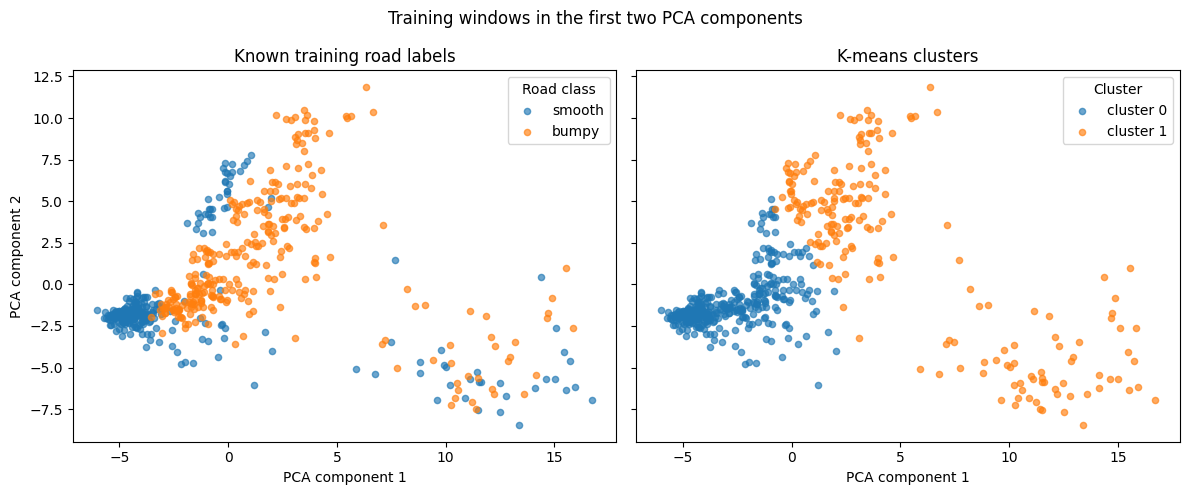

In [7]:
best_cluster_labels = fitted_unsupervised_models[best_unsupervised_model_name]

figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for road_class, color in [("smooth", "tab:blue"), ("bumpy", "tab:orange")]:
    mask = y_train.to_numpy() == road_class
    axes[0].scatter(
        X_unsupervised_train[mask, 0],
        X_unsupervised_train[mask, 1],
        label=road_class,
        color=color,
        alpha=0.65,
        s=20,
    )
axes[0].set_title("Known training road labels")
axes[0].set_xlabel("PCA component 1")
axes[0].set_ylabel("PCA component 2")
axes[0].legend(title="Road class")

for cluster_id in sorted(set(best_cluster_labels)):
    mask = best_cluster_labels == cluster_id
    label = "noise" if cluster_id == -1 else f"cluster {cluster_id}"
    axes[1].scatter(
        X_unsupervised_train[mask, 0],
        X_unsupervised_train[mask, 1],
        label=label,
        alpha=0.65,
        s=20,
    )
axes[1].set_title(f"{best_unsupervised_model_name} clusters")
axes[1].set_xlabel("PCA component 1")
axes[1].legend(title="Cluster")
figure.suptitle("Training windows in the first two PCA components")
figure.tight_layout()
plt.show()


## 5. Supervised versus unsupervised comparison and final model

The supervised model is selected by grouped cross-validation in Part 2 and then checked on held-out rides. Its held-out accuracy and the unsupervised training agreement measure different things and are not directly comparable. Supervised learning suits our labelled smooth/bumpy prediction task. Clustering is useful for exploring groups when labels are unavailable, but clusters need not correspond to road classes. The cross-validation-selected supervised model is used for deployment.

In [8]:
supervised_test_accuracy = float(test_results.iloc[0]["test_accuracy"])
best_unsupervised_result = unsupervised_comparison.iloc[0]

model_comparison = pd.DataFrame([
    {
        "approach": "Supervised",
        "model": best_model_name,
        "score": supervised_test_accuracy,
        "metric": "held-out classification accuracy",
        "evaluation_data": "held-out rides from Part 2",
        "purpose": "predict a road class for a new window",
    },
    {
        "approach": "Unsupervised",
        "model": best_unsupervised_model_name,
        "score": best_unsupervised_result["cluster_agreement_accuracy"],
        "metric": "exploratory agreement over all training windows",
        "evaluation_data": "training rides after clustering",
        "purpose": "explore whether natural groups resemble the road classes",
    },
])

final_choice = {
    "approach": "Supervised",
    "selected_model": best_model_name,
    "reason": "Selected by Part 2 grouped cross-validation; held-out rides provide the final evaluation. It can predict new windows.",
}

model_comparison.to_csv(
    unsupervised_dir / "supervised_unsupervised_comparison.csv", index=False
)
pd.DataFrame([final_choice]).to_csv(
    unsupervised_dir / "final_model_selection.csv", index=False
)

print(f"Final model for deployment: {best_model_name}")
model_comparison.round(3)


Final model for deployment: Random forest


,approach,model,score,metric,evaluation_data,purpose
0,Supervised,Random forest,0.963,held-out classification accuracy,held-out rides from Part 2,predict a road class for a new window
1,Unsupervised,K-means,0.656,exploratory agreement over all training windows,training rides after clustering,explore whether natural groups resemble the ro...


## 6. Deploy the final model on the independent recording

The independent deployment recording is kept outside model training and evaluation. The selected supervised pipeline is applied after the same alignment, windowing and feature calculation used for the labelled recordings.


In [9]:
deployment_source_dir = Path("DeploymentData")
deployment_dir = Path("data/deployment/current")
deployment_dir.mkdir(parents=True, exist_ok=True)

deployment_sensor_paths = sorted(deployment_source_dir.rglob("*.csv"))
if not deployment_sensor_paths:
    raise FileNotFoundError(f"No deployment CSV files found in {deployment_source_dir}")

deployment_streams = {}
for sensor_path in deployment_sensor_paths:
    sensor_name = sensor_path.stem.lower()
    if sensor_name not in {"accelerometer", "gyroscope", "gravity"}:
        continue
    sensor_data = pd.read_csv(sensor_path)
    if sensor_data.isna().any().any() or not np.isfinite(sensor_data.select_dtypes(include=np.number)).all().all():
        raise ValueError(f"Deployment stream contains missing or infinite values: {sensor_path}")
    deployment_streams[sensor_name.title()] = sensor_data

expected_sensors = {"Accelerometer", "Gyroscope", "Gravity"}
if set(deployment_streams) != expected_sensors:
    raise ValueError(f"Expected {expected_sensors}; found {set(deployment_streams)}")

deployment_recording = align_sensor_streams(deployment_streams)
deployment_rate_hz, deployment_max_gap_seconds = sampling_diagnostics(deployment_recording)
deployment_features = pd.DataFrame(make_window_features(
    deployment_recording,
    recording_id="DeploymentData",
    participant_id="external",
    road_class=None,
))
deployment_X = deployment_features[feature_columns]

if deployment_X.columns.tolist() != feature_columns:
    raise ValueError("Deployment feature table does not match the labelled feature schema.")

print(f"Deployment aligned samples: {len(deployment_recording)}")
print(f"Deployment median sample rate: {deployment_rate_hz:.2f} Hz; largest gap: {deployment_max_gap_seconds:.4f} s")
print(f"Deployment windows: {len(deployment_features)}")


Deployment aligned samples: 101926
Deployment median sample rate: 99.49 Hz; largest gap: 0.0101 s
Deployment windows: 406


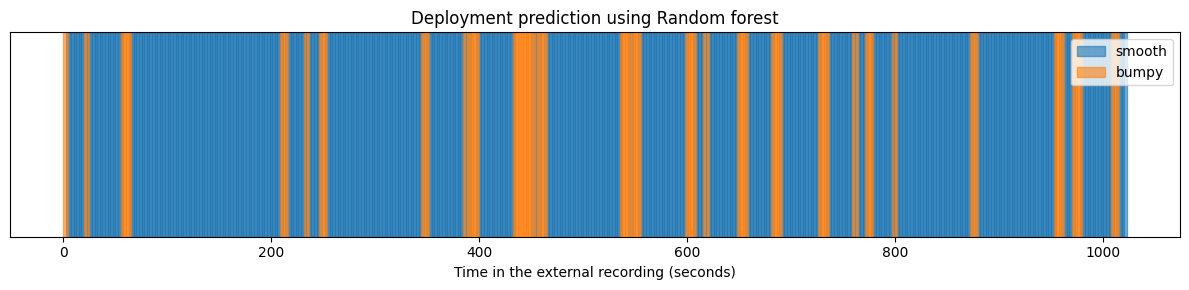

Deployment model: Random forest
predicted_class
smooth    347
bumpy      59
Name: windows, dtype: int64


In [10]:
deployment_predictions = best_pipeline.predict(deployment_X)
deployment_output = deployment_features[[
    "recording_id",
    "window_start_seconds",
    "window_end_seconds",
]].copy()
deployment_output["predicted_class"] = deployment_predictions

deployment_output.to_csv(
    deployment_dir / "deployment_window_predictions.csv", index=False
)

class_colours = {"smooth": "tab:blue", "bumpy": "tab:orange"}
figure, axis = plt.subplots(figsize=(12, 3))
for road_class, color in class_colours.items():
    rows = deployment_output[deployment_output["predicted_class"] == road_class]
    for _, row in rows.iterrows():
        axis.axvspan(
            row["window_start_seconds"],
            row["window_end_seconds"],
            color=color,
            alpha=0.6,
        )
axis.set_xlabel("Time in the external recording (seconds)")
axis.set_yticks([])
axis.set_title(f"Deployment prediction using {best_model_name}")
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.6, label=road_class)
    for road_class, color in class_colours.items()
]
axis.legend(handles=legend_handles, loc="upper right")
figure.tight_layout()
figure.savefig(deployment_dir / "deployment_lane_quality_timeline.png", dpi=150)
plt.show()

print(f"Deployment model: {best_model_name}")
print(deployment_output["predicted_class"].value_counts().rename("windows"))


## 7. Part 3 outputs and limitations

Clustering uses label-free feature preparation, followed by road labels only for exploratory interpretation. Agreement is calculated on training windows and may increase with the number of clusters. DBSCAN noise remains unassigned. The supervised model is selected through grouped cross-validation, evaluated on held-out rides, and applied to the external recording after the same feature calculation. The external recording has no ground-truth labels, so its predictions are not a measured deployment accuracy. Results remain limited by two riders, shared routes/sessions and possible phone handling at recording boundaries.

In [11]:
print("Saved Part 3 outputs:")
for path in sorted(unsupervised_dir.glob("*.csv")):
    print(f"- {path}")
for path in sorted(deployment_dir.glob("*")):
    print(f"- {path}")


Saved Part 3 outputs:
- data/features/unsupervised/current/final_model_selection.csv
- data/features/unsupervised/current/supervised_unsupervised_comparison.csv
- data/features/unsupervised/current/unsupervised_model_comparison.csv
- data/deployment/current/deployment_lane_quality_timeline.png
- data/deployment/current/deployment_window_predictions.csv
